# 230473G - Peramunage D.S

__EN3160 Assignment 1 on Intensity Transformations and Neighborhood
Filtering__

### (1). Intensity transformation

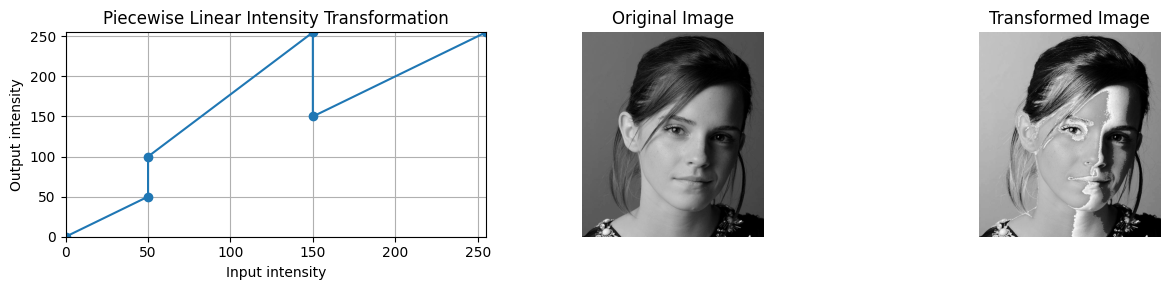

In [304]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
##piecewise linear intensity transformation
breakpoints = np.array([[0, 0],[50, 50],[50, 100],[150, 255],[150, 150],[255, 255]], dtype=np.float32)
x = breakpoints[:, 0]
y = breakpoints[:, 1]
plt.figure(figsize=(13, 3))
plt.subplot(1, 3, 1)
plt.plot(x, y, marker='o')
plt.xlabel("Input intensity")
plt.ylabel("Output intensity")
plt.title("Piecewise Linear Intensity Transformation")
plt.xlim(0, 255)
plt.ylim(0, 255)
plt.grid(True)
## define the intensity transformation function
def intensity_transformation(im,breakpoints):
    x = breakpoints[:, 0]
    y = breakpoints[:, 1]
    im_transformed = np.interp(im.flatten(), x, y)
    return im_transformed.reshape(im.shape).astype(np.uint8)
## read the image
im = cv2.imread(r"C:\my files\5th sem\CV\assignments\images\images\q1.jpeg",cv2.IMREAD_GRAYSCALE)
## apply the intensity transformation
transformed = intensity_transformation(im, breakpoints)
plt.subplot(1, 3, 2)
plt.imshow(im, cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.subplot(1, 3, 3)
plt.imshow(transformed, cmap="gray")
plt.title("Transformed Image")
plt.axis("off")
plt.tight_layout()
plt.show()

I implemented a piecewise linear intensity transformation using selected breakpoints.The slope of each segment determines whether an intensity range is expanded or compressed.According to the intensity graph the main intensity veriation happens in the 50 to 150 intensity range,the slope is 1.55.As a result, regions containing these intensities appear to be more lighter than before. 



### (2).Brain image enhancement

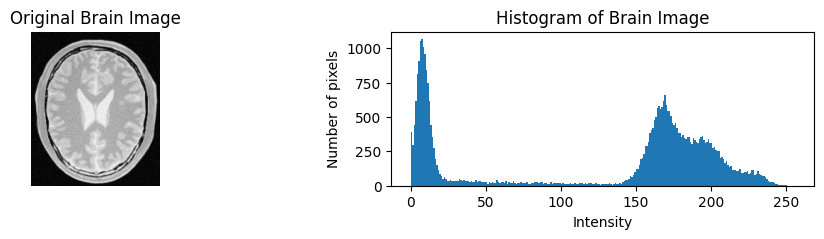

In [305]:
brain = cv2.imread(r"C:\my files\5th sem\CV\assignments\images\images\q2.jpeg", cv2.IMREAD_GRAYSCALE)
plt.figure(figsize=(12, 2))
plt.subplot(1, 2, 1)
plt.imshow(brain, cmap="gray")
plt.title("Original Brain Image")
plt.axis("off")
##get the distribution of pixel intensities in the brain image
plt.subplot(1, 2, 2)
plt.hist(brain.ravel(), bins=256, range=(0, 256))
plt.xlabel("Intensity")
plt.ylabel("Number of pixels")
plt.title("Histogram of Brain Image")
plt.show()


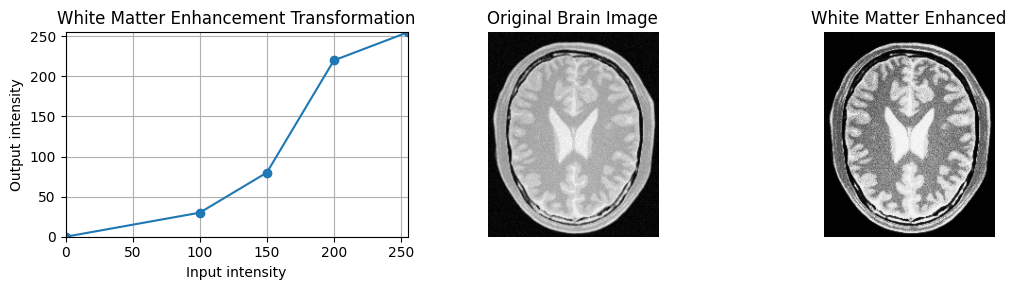

In [306]:
## according to the histogram most of the white matter approximatelty in the range of 150 - 220 intensities. So that we should define new breakpoints to enhance the white matters.
white_breakpoints = np.array([[0, 0],[100, 30],[150, 80],[200, 220],[255, 255]], dtype=np.float32)
plt.figure(figsize=(11, 3))
plt.subplot(1, 3, 1)
plt.plot(white_breakpoints[:, 0],white_breakpoints[:, 1],marker='o')
plt.xlabel("Input intensity")
plt.ylabel("Output intensity")
plt.title("White Matter Enhancement Transformation")
plt.xlim(0, 255)
plt.ylim(0, 255)
plt.grid(True)
white_enhanced = intensity_transformation(brain,white_breakpoints)
## plot the original brain image and the enhanced image
plt.subplot(1, 3, 2)
plt.imshow(brain, cmap="gray")
plt.title("Original Brain Image")
plt.axis("off")
plt.subplot(1, 3, 3)
plt.imshow(white_enhanced, cmap="gray")
plt.title("White Matter Enhanced")
plt.axis("off")
plt.tight_layout()
plt.show()

For white matter, I selected breakpoints to emphasize the 150-220 intensity range.The transformation curve has a relatively higher slope in that region, which expands the intensity differences between pixels. As a result, the contrast of the corresponding structures is increased and the white matter becomes more distinguishable from surrounding regions. The lower-intensity regions are affected less significantly, allowing the transformation to focus mainly on the desired tissue range.

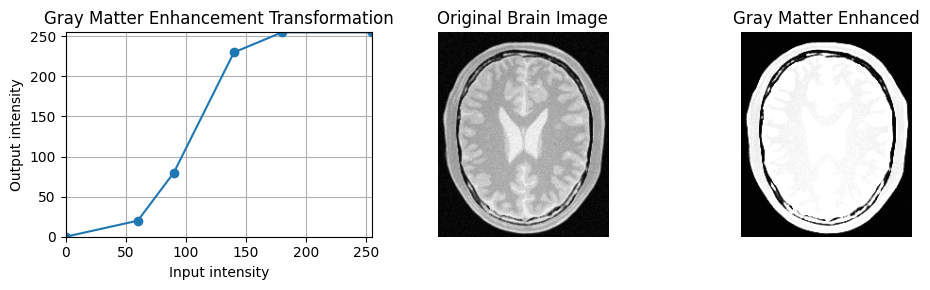

In [307]:
##according to the histogram most of the gray matters in the ranges of approximately 80 - 150 intensities.
gray_breakpoints = np.array([[0, 0],[60, 20],[90, 80],[140, 230],[180, 255],[255, 255]], dtype=np.float32)
plt.figure(figsize=(10, 3))
plt.subplot(1, 3, 1)
plt.plot(gray_breakpoints[:, 0],gray_breakpoints[:, 1],marker='o')
plt.xlabel("Input intensity")
plt.ylabel("Output intensity")
plt.title("Gray Matter Enhancement Transformation")
plt.xlim(0, 255)
plt.ylim(0, 255)
plt.grid(True)
gray_enhanced = intensity_transformation(brain,gray_breakpoints)
plt.subplot(1, 3, 2)
plt.imshow(brain, cmap="gray")
plt.title("Original Brain Image")
plt.axis("off")
plt.subplot(1, 3, 3)
plt.imshow(gray_enhanced, cmap="gray")
plt.title("Gray Matter Enhanced")
plt.axis("off")
plt.tight_layout()
plt.show()

For the gray matter enhancement, a different set of breakpoints was used because the gray matter occupies a different intensity range from the white matter(80 to 150 intensity range). The transformation was designed to increase the contrast within this range. By expanding the differences between gray-matter intensities, structures that were less distinguishable in the original image become more visible after the transformation.

### (3).Gamma correction

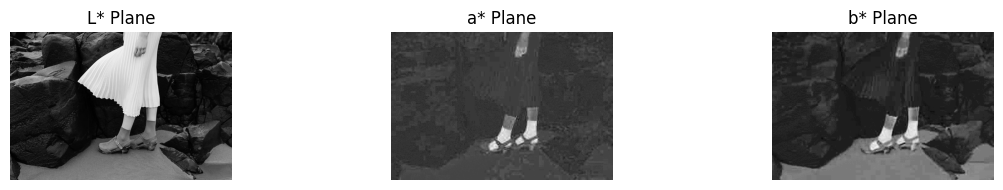

In [340]:
img = cv2.imread(r"C:\my files\5th sem\CV\assignments\images\images\q3.jpeg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
## convert the image to LAB color space and split the channels
lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
L, a, b = cv2.split(lab)
## visualize the L*, a*, and b* planes
plt.figure(figsize=(12, 2))
plt.subplot(1, 3, 1)
plt.imshow(L, cmap="gray")
plt.title("L* Plane")
plt.axis("off")
plt.subplot(1, 3, 2)
plt.imshow(a, cmap="gray")
plt.title("a* Plane")
plt.axis("off")
plt.subplot(1, 3, 3)
plt.imshow(b, cmap="gray")
plt.title("b* Plane")
plt.axis("off")
plt.tight_layout()
plt.show()

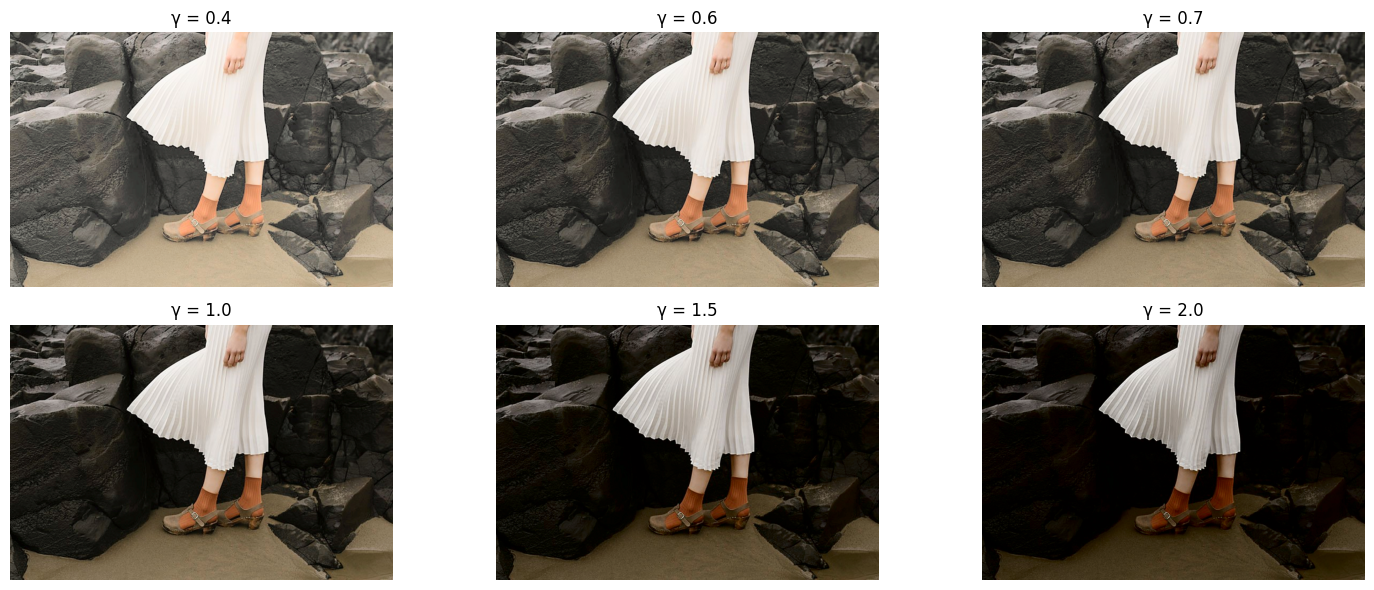

In [343]:
gammas = [0.4, 0.6,0.7, 1.0, 1.5, 2.0]
plt.figure(figsize=(15, 6))
for i, gamma in enumerate(gammas):
    L_norm = L.astype(np.float32) / 255.0
    L_gamma = np.power(L_norm, gamma)
    L_gamma = np.clip(L_gamma * 255,0,255).astype(np.uint8)
    lab_gamma = cv2.merge([L_gamma, a, b])
    corrected = cv2.cvtColor(lab_gamma,cv2.COLOR_LAB2RGB)
    plt.subplot(2, 3, i + 1)
    plt.imshow(corrected)
    plt.title(f"γ = {gamma}")
    plt.axis("off")
plt.tight_layout()
plt.show()

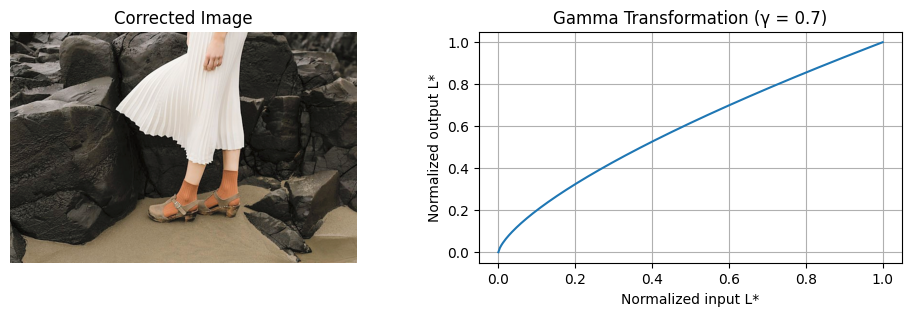

In [310]:
gamma = 0.7
L_norm = L.astype(np.float32) / 255.0
L_gamma = np.power(L_norm, gamma)
L_gamma = np.clip(L_gamma * 255,0,255).astype(np.uint8)
lab_gamma = cv2.merge([L_gamma, a, b])
corrected_image = cv2.cvtColor(lab_gamma,cv2.COLOR_LAB2RGB)
r = np.linspace(0, 1, 256)
s = r ** gamma
plt.figure(figsize=(12, 3))
## plot the corrected image and the gamma transformation function
plt.subplot(1, 2, 1)
plt.imshow(corrected_image)
plt.title("Corrected Image")
plt.axis("off")
## plot the gamma transformation function
plt.subplot(1, 2, 2)
plt.plot(r, s)
plt.xlabel("Normalized input L*")
plt.ylabel("Normalized output L*")
plt.title(f"Gamma Transformation (γ = {gamma})")
plt.grid(True)
plt.show()



Since gamma < 1 the curve should be above the diagonal, showing that the output lightness is increased.

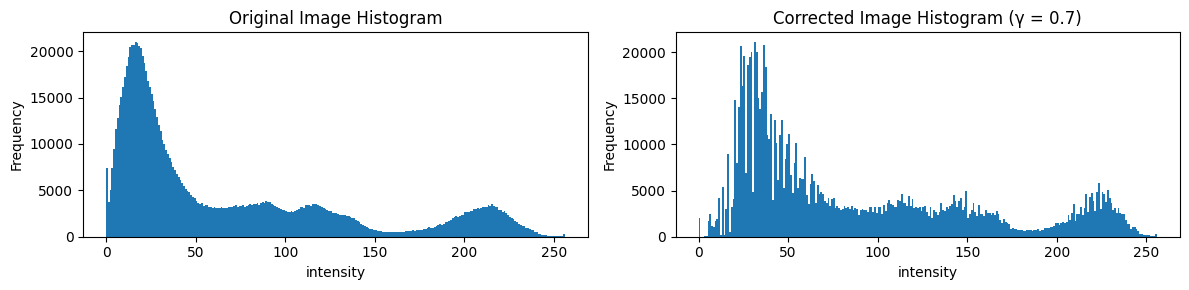

In [311]:
plt.figure(figsize=(12, 3))
## plot the histograms of the original and corrected images
plt.subplot(1, 2, 1)
plt.hist(img_rgb.ravel(),bins=256,range=(0, 256))
plt.xlabel("intensity")
plt.ylabel("Frequency")
plt.title("Original Image Histogram")
## plot the histogram of the corrected image
plt.subplot(1, 2, 2)
plt.hist(corrected_image.ravel(),bins=256,range=(0, 256))
plt.xlabel("intensity")
plt.ylabel("Frequency")
plt.title(f"Corrected Image Histogram (γ = {gamma})")
plt.tight_layout()
plt.show()

Gamma correction was applied to the L plane of the Lab image using a gamma value of 0.7. Since the gamma value is less than 1, darker and mid-level intensities are increased, making details in darker regions more visible. The histogram after correction shows a shift toward higher intensity values. Since only the L plane was modified, the lightness of the image was changed while the color information in the a^* and b^* planes was preserved.

### (4). Vibrance Enhancement

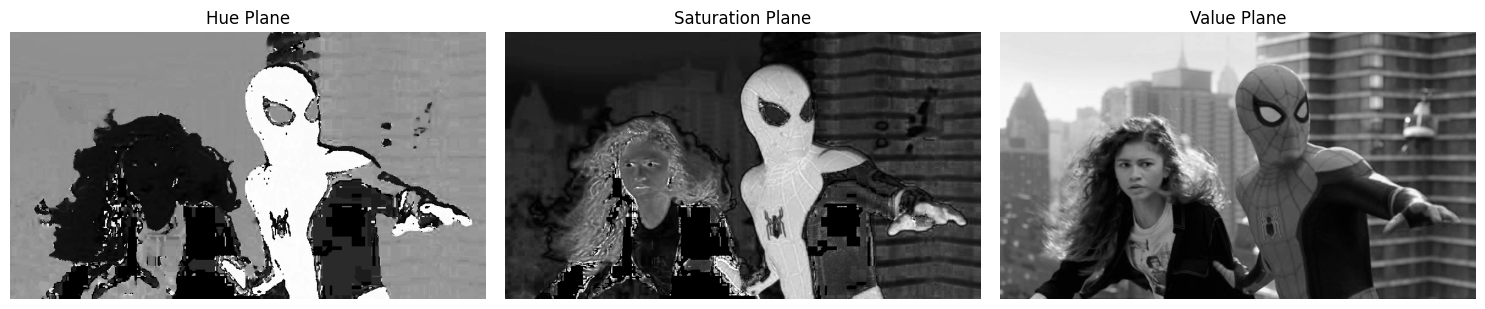

In [347]:
img = cv2.imread(r"C:\my files\5th sem\CV\assignments\images\images\q4.jpeg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
## convert the image to HSV color space and split the channels
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
## split the HSV channels and visualize them
H, S, V = cv2.split(hsv)
plt.figure(figsize=(15, 3))
plt.subplot(1, 3, 1)
plt.imshow(H, cmap="gray")
plt.title("Hue Plane")
plt.axis("off")
plt.subplot(1, 3, 2)
plt.imshow(S, cmap="gray")
plt.title("Saturation Plane")
plt.axis("off")
plt.subplot(1, 3, 3)
plt.imshow(V, cmap="gray")
plt.title("Value Plane")
plt.axis("off")
plt.tight_layout()
plt.show()

Since the vibrance is related to colour saturation I modify the saturation while Hue and Value unchange.

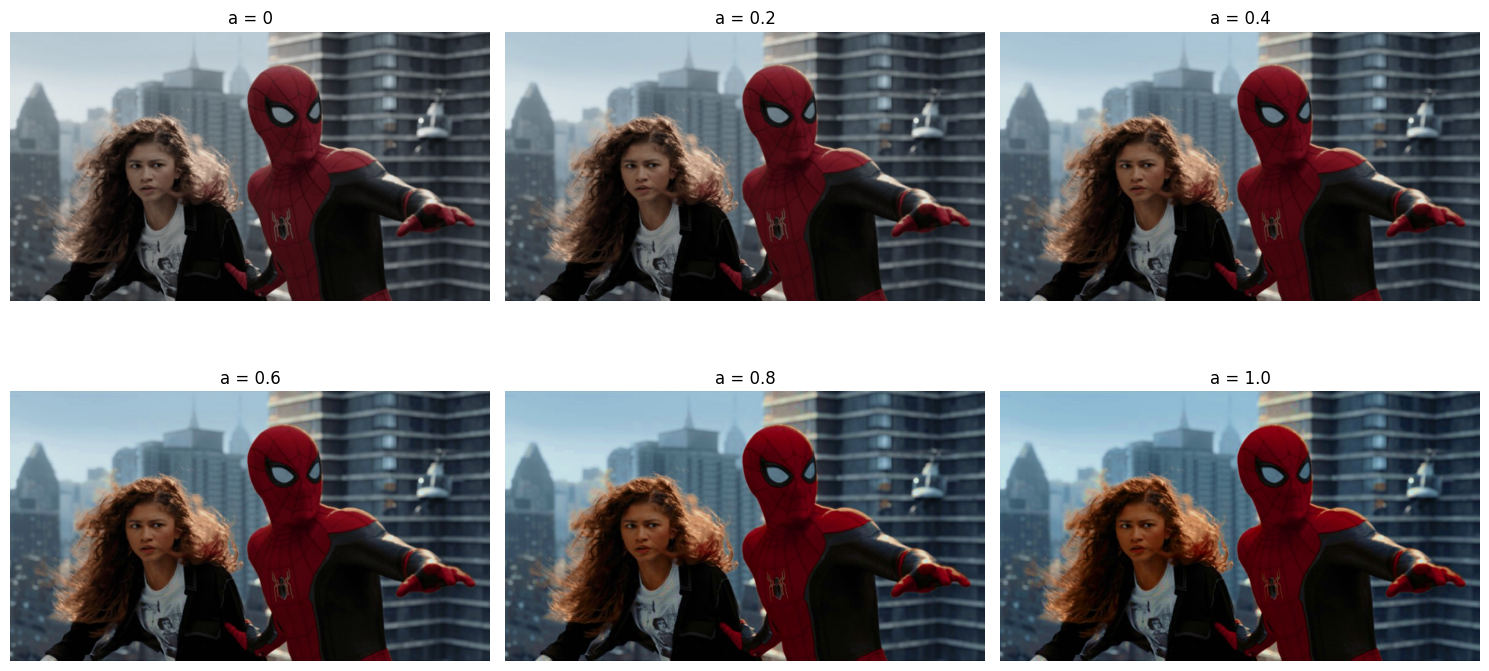

In [352]:
## for the different values of a, we will create a lookup table for the saturation channel and apply it to the image
a_values = [0,0.2, 0.4, 0.6, 0.8, 1.0]
sigma = 70
## lookup table for the saturation channel
x = np.arange(256)
lookup_table = np.clip(x + a * 128 * np.exp(-((x - 128) ** 2) / (2 * sigma ** 2)),0,255).astype(np.uint8)
plt.figure(figsize=(15, 8))
for i, a in enumerate(a_values):
    lookup_table = np.clip(x + a * 128 * np.exp(-((x - 128) ** 2) / (2 * sigma ** 2)),0,255).astype(np.uint8)
    S_enhanced = lookup_table[S]
    hsv_enhanced = cv2.merge([H,S_enhanced,V])
    enhanced_bgr = cv2.cvtColor(hsv_enhanced,cv2.COLOR_HSV2BGR)
    enhanced_rgb = cv2.cvtColor(enhanced_bgr,cv2.COLOR_BGR2RGB)
    plt.subplot(2, 3, i + 1)
    plt.imshow(enhanced_rgb)
    plt.title(f"a = {a}")
    plt.axis("off")
plt.tight_layout()
plt.show()

(np.float64(-0.5), np.float64(779.5), np.float64(437.5), np.float64(-0.5))

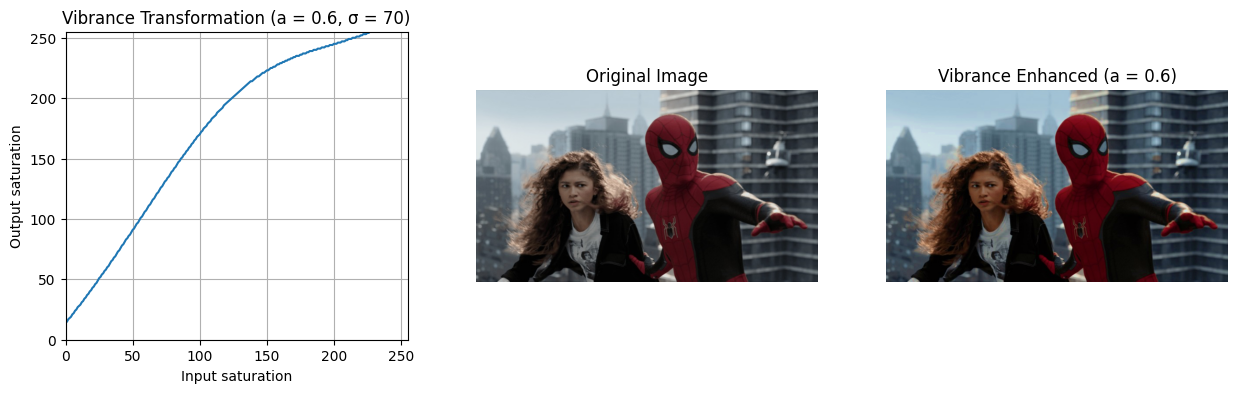

In [350]:
## choose a = 0.6 for the final transformation
a = 0.6
transformation = np.clip(x + a * 128 * np.exp(-((x - 128) ** 2) / (2 * sigma ** 2)),0,255).astype(np.uint8)
plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.plot(x, transformation)
plt.xlabel("Input saturation")
plt.ylabel("Output saturation")
plt.title(f"Vibrance Transformation (a = {a}, σ = {sigma})")
plt.xlim(0, 255)
plt.ylim(0, 255)
plt.grid(True)
S_enhanced = transformation[S]
hsv_enhanced = cv2.merge([H,S_enhanced,V])
enhanced_bgr = cv2.cvtColor(hsv_enhanced,cv2.COLOR_HSV2BGR)
enhanced_rgb = cv2.cvtColor(enhanced_bgr,cv2.COLOR_BGR2RGB)
## plot the original and vibrance enhanced images
plt.subplot(1, 3, 2)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")
## plot the vibrance enhanced image
plt.subplot(1, 3, 3)
plt.imshow(enhanced_rgb)
plt.title(f"Vibrance Enhanced (a = {a})")
plt.axis("off")

Vibrance enhancement was applied to the saturation plane of the HSV image using the given nonlinear transformation with sigma=70 and a= 0.6. The transformation increases saturation mainly around the middle saturation range, while avoiding excessive enhancement of already highly saturated pixels. As a result, the colors in the enhanced image appear more vivid compared with the original image. Different values of "a" were tested, and the selected value provided a visually pleasing balance without excessive color saturation.

### (5). Histogram Equalization

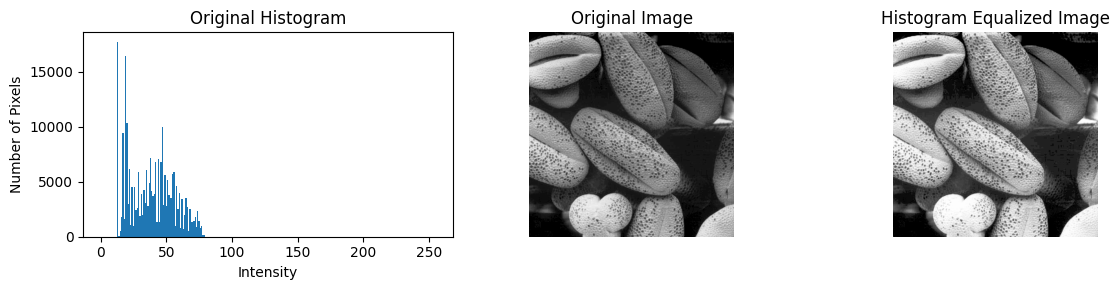

In [ ]:
img = cv2.imread(r"C:\my files\5th sem\CV\assignments\images\images\shells.TIF", cv2.IMREAD_GRAYSCALE)
hist = np.bincount(img.ravel(), minlength=256)
plt.figure(figsize=(12, 3))
plt.subplot(1, 3, 1)
plt.bar(np.arange(256), hist, width=1.0)
plt.xlabel("Intensity")
plt.ylabel("Number of Pixels")
plt.title("Original Histogram")
## compute the cumulative distribution function (CDF) and normalize it to the range [0, 255]
cdf = np.cumsum(hist)
cdf_min = cdf[cdf > 0][0]
num_pixels = img.size
cdf_normalized = ((cdf - cdf_min) / (num_pixels - cdf_min)) * 255
cdf_normalized = np.clip(cdf_normalized, 0, 255).astype(np.uint8)
equalized_img = cdf_normalized[img]
## plot the original image and the histogram equalized image
plt.subplot(1, 3, 2)
plt.imshow(img, cmap="gray")
plt.title("Original Image")
plt.axis("off")
## plot the histogram equalized image
plt.subplot(1, 3, 3)
plt.imshow(equalized_img, cmap="gray")
plt.title("Histogram Equalized Image")
plt.axis("off")
plt.tight_layout() 
plt.show()

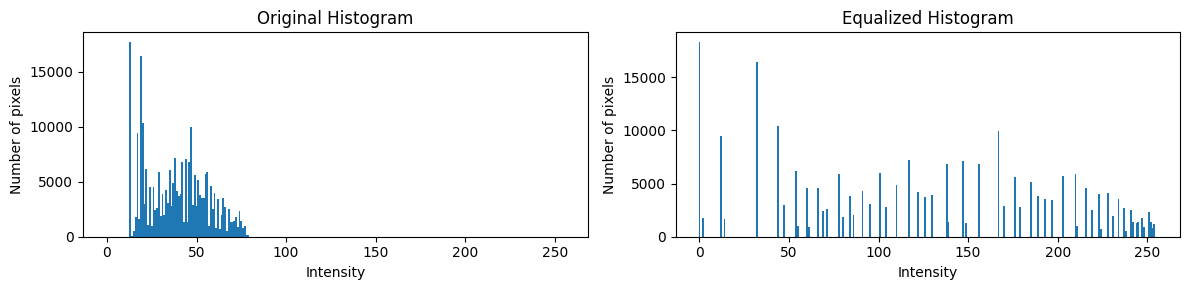

In [ ]:
equalized_hist = np.bincount(equalized_img.ravel(),minlength=256)
plt.figure(figsize=(12, 3))
## plot the histograms of the original and equalized images
plt.subplot(1, 2, 1)
plt.bar(np.arange(256),hist,width=1.0)
plt.xlabel("Intensity")
plt.ylabel("Number of pixels")
plt.title("Original Histogram")
## plot the histogram of the equalized image
plt.subplot(1, 2, 2)
plt.bar(np.arange(256),equalized_hist,width=1)
plt.xlabel("Intensity")
plt.ylabel("Number of pixels")
plt.title("Equalized Histogram")
plt.tight_layout()
plt.show()

Histogram equalization was implemented manually using the histogram and cumulative distribution function (CDF) of the input image. The CDF was used to generate an intensity mapping that redistributes the pixel values over a wider range. Compared with the original image, the equalized image shows improved contrast, particularly in regions where the original intensity values were concentrated in a limited range. The histograms before and after equalization demonstrate this redistribution of intensity values.

### (6).Histogram Equalization of the Foreground

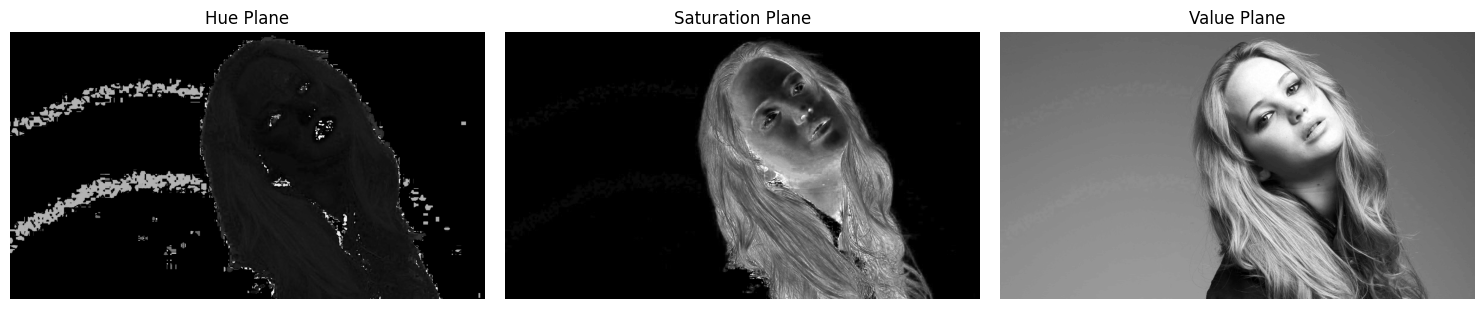

In [ ]:
img = cv2.imread(r"C:\my files\5th sem\CV\assignments\images\images\q6.jpeg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
H, S, V = cv2.split(hsv)
plt.figure(figsize=(15, 3))
plt.subplot(1, 3, 1)
plt.imshow(H, cmap="gray")
plt.title("Hue Plane")
plt.axis("off")
plt.subplot(1, 3, 2)
plt.imshow(S, cmap="gray")
plt.title("Saturation Plane")
plt.axis("off")
plt.subplot(1, 3, 3)
plt.imshow(V, cmap="gray")
plt.title("Value Plane")
plt.axis("off")
plt.tight_layout()
plt.show()

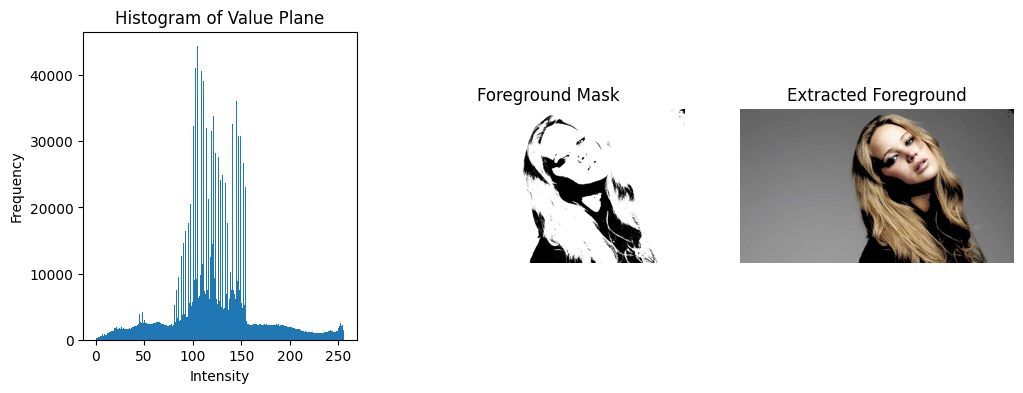

In [ ]:
## Acoording to the H,S and V planes the Value plane gives the clearest separation between the foreground and background so that Value(V) plane is the best plane for the threshold.
plt.figure(figsize=(12, 4))\
## plot the histogram of the value plane
plt.subplot(1, 3, 1)
plt.hist(V.ravel(),bins=256,range=(0, 256))
plt.xlabel("Intensity")
plt.ylabel("Frequency")
plt.title("Histogram of Value Plane")
threshold = 80
_, mask = cv2.threshold(V, threshold, 255, cv2.THRESH_BINARY)
## plot the foreground mask and the extracted foreground
plt.subplot(1, 3, 2)
plt.imshow(mask, cmap="gray")
plt.title("Foreground Mask")
plt.axis("off")
foreground = cv2.bitwise_and(img,img,mask=mask)
foreground_rgb = cv2.cvtColor(foreground,cv2.COLOR_BGR2RGB)
## plot the extracted foreground
plt.subplot(1, 3, 3)
plt.imshow(foreground_rgb)
plt.title("Extracted Foreground")
plt.axis("off")
plt.show()


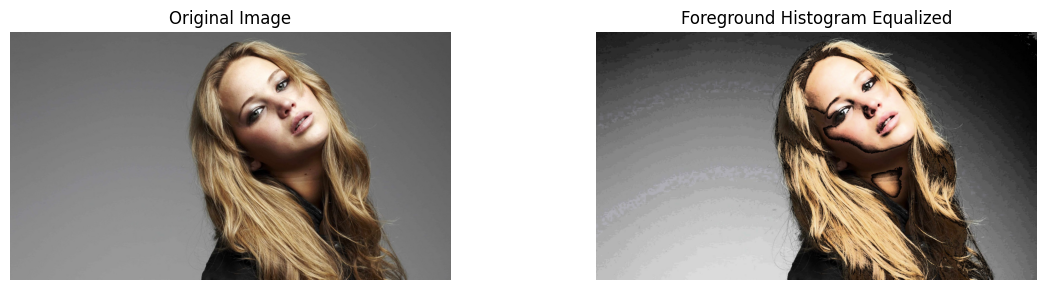

In [ ]:
foreground_V = V[mask > 0]
hist_fg = np.bincount(foreground_V,minlength=256)
cdf_fg = np.cumsum(hist_fg)
cdf_min_fg = cdf_fg[cdf_fg > 0][0]
num_fg_pixels = foreground_V.size
mapping_fg = ((cdf_fg - cdf_min_fg) /(num_fg_pixels - cdf_min_fg)) * 255
mapping_fg = np.clip(mapping_fg,0,255).astype(np.uint8)
V_equalized = V.copy()
V_equalized[mask > 0] = (mapping_fg[V[mask > 0]])
## merge the H, S, and equalized V channels to get the final HSV image
hsv_result = cv2.merge([H,S,V_equalized])
## convert the HSV image back to BGR color space
result = cv2.cvtColor(hsv_result,cv2.COLOR_HSV2BGR)
## convert the BGR image to RGB for displaying with matplotlib
result_rgb = cv2.cvtColor(result,cv2.COLOR_BGR2RGB)
background_mask = cv2.bitwise_not(mask)
background = cv2.bitwise_and(img,img,mask=background_mask)
final_result = np.where(mask[:, :, None] > 0,result,background).astype(np.uint8)
final_rgb = cv2.cvtColor(final_result,cv2.COLOR_BGR2RGB)
plt.figure(figsize=(12, 3))
plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(final_rgb)
plt.title("Foreground Histogram Equalized")
plt.axis("off")
plt.tight_layout()
plt.show()

The image was converted to HSV and the V plane was selected for foreground extraction. A threshold was applied to create a binary foreground mask, which was then used to isolate the foreground. Histogram equalization was performed only on the foreground pixels using their CDF, while the background was kept unchanged. The equalized foreground was then combined with the original background, resulting in improved contrast in the selected foreground region while preserving the surrounding background.

### (7). Sobel filtering

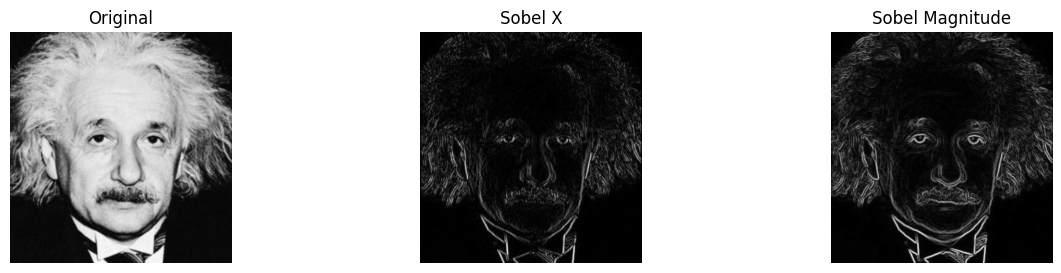

In [ ]:
img = cv2.imread(r"C:\my files\5th sem\CV\assignments\images\images\q7.jpeg", cv2.IMREAD_GRAYSCALE)
## define Sobel kernels for x and y directions
Gx = np.array([[-1, 0, 1],[-2, 0, 2],[-1, 0, 1]], dtype=np.float32)
Gy = np.array([[-1, -2, -1],[ 0,  0,  0],[ 1,  2,  1]], dtype=np.float32)
Ix = cv2.filter2D(img, cv2.CV_32F, Gx)
Iy = cv2.filter2D(img, cv2.CV_32F, Gy)
magnitude = np.sqrt(Ix**2 + Iy**2)
magnitude_display = cv2.normalize(magnitude,None,0,255,cv2.NORM_MINMAX).astype(np.uint8)
plt.figure(figsize=(15,3))
## plot the original image, Sobel X, and Sobel magnitude images

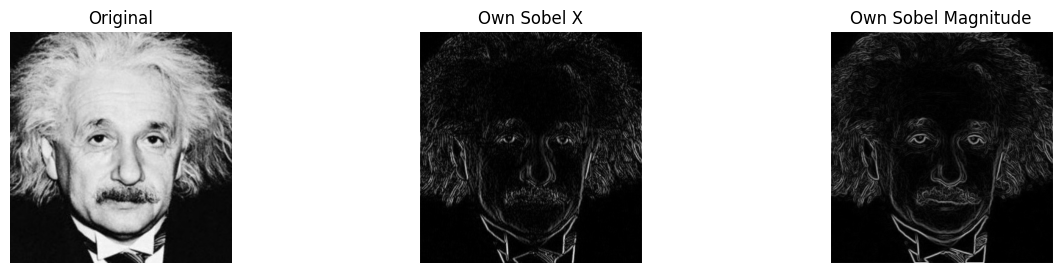

In [ ]:
## define my own sobel filter
def convolution(im, kernel):
    kh, kw = kernel.shape
    pad_h = kh // 2
    pad_w = kw // 2
    padded = np.pad(im,((pad_h, pad_h), (pad_w, pad_w)),mode='constant')
    output = np.zeros_like(im, dtype=np.float32)
    for i in range(im.shape[0]):
        for j in range(im.shape[1]):
            region = padded[i:i+kh,j:j+kw]
            output[i, j] = np.sum(region * kernel)
    return output
Ix_own = convolution(img.astype(np.float32), Gx)
Iy_own = convolution(img.astype(np.float32), Gy)
magnitude_own = np.sqrt(Ix_own**2 + Iy_own**2)
magnitude_own_display = cv2.normalize(magnitude_own,None,0,255,cv2.NORM_MINMAX).astype(np.uint8)
plt.figure(figsize=(15,3))
## plot the original image, Sobel X, and Sobel magnitude images


In [ ]:
## Compare OpenCV vs your implementation
difference = np.abs(magnitude - magnitude_own)
print("Maximum difference:", np.max(difference))
print("Mean difference:", np.mean(difference))

Maximum difference: 987.0005
Mean difference: 1.7478977


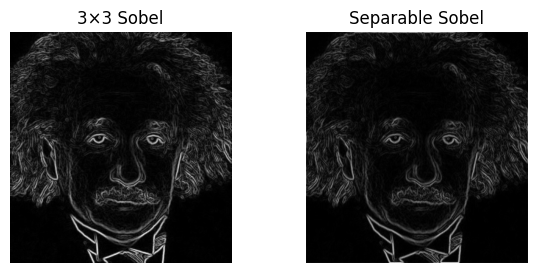

In [ ]:
### define the separable Sobel filter for x direction
smooth = np.array([[1],[2],[1]], dtype=np.float32)
derivative = np.array([[-1, 0, 1]], dtype=np.float32)
Gx_separable = smooth @ derivative
## define the separable Sobel filter for y direction
derivative_vertical = np.array([[-1],[0],[1]], dtype=np.float32)
smooth_horizontal = np.array([[1, 2, 1]], dtype=np.float32)
Gy_separable = derivative_vertical @ smooth_horizontal
Ix_step1 = convolution(img.astype(np.float32), smooth)
Ix_sep = convolution(Ix_step1, derivative)
Iy_step1 = convolution(img.astype(np.float32), smooth_horizontal.T)
Iy_sep = convolution(Iy_step1, derivative_vertical)
magnitude_sep = np.sqrt(Ix_sep**2 + Iy_sep**2)
magnitude_sep_display = cv2.normalize(magnitude_sep,None,0,255,cv2.NORM_MINMAX).astype(np.uint8)
plt.figure(figsize=(7,3))
## plot the original image, Sobel X, and Sobel magnitude images

meaning of the seperable:A filter is separable if a 2D convolution can be performed as two consecutive 1D convolutions. The Sobel filters are separable because their 3×3 kernels can be expressed as the outer product of two 1D kernels. Therefore, instead of performing a 3×3 convolution directly, the filtering can be performed using two 1D convolutions, reducing the computational complexity.


### (8). nearest neighbor and bilinear interpolation

In [ ]:
img = cv2.imread(r"C:\my files\5th sem\CV\assignments\images\images\im02small.png", cv2.IMREAD_GRAYSCALE)
## nearest neighbor interpolation
def zoom_nearest(im, s):
    h, w = im.shape
    new_h = int(h * s)
    new_w = int(w * s)
    output = np.zeros((new_h, new_w), dtype=im.dtype)
    for y in range(new_h):
        for x in range(new_w):
            src_y = int(round(y / s))
            src_x = int(round(x / s))
            # Keep coordinates inside image
            src_y = min(src_y, h - 1)
            src_x = min(src_x, w - 1)
            output[y, x] = im[src_y, src_x]
    return output
s = 4
nearest = zoom_nearest(img, s)
print("Original:", img.shape)
print("Nearest:", nearest.shape)

Original: (300, 480)
Nearest: (1200, 1920)


In [ ]:
## bilinear interpolation
def zoom_bilinear(im, s):
    h, w = im.shape
    new_h = int(h * s)
    new_w = int(w * s)
    output = np.zeros((new_h, new_w), dtype=np.float32)
    for y in range(new_h):
        src_y = y / s
        y0 = int(np.floor(src_y))
        y1 = min(y0 + 1, h - 1)
        b = src_y - y0
        for x in range(new_w):
            src_x = x / s
            x0 = int(np.floor(src_x))
            x1 = min(x0 + 1, w - 1)
            a = src_x - x0
            Q11 = im[y0, x0]
            Q21 = im[y0, x1]
            Q12 = im[y1, x0]
            Q22 = im[y1, x1]
            value = (Q11 * (1-a) * (1-b) +Q21 * a * (1-b) +Q12 * (1-a) * b +Q22 * a * b)
            output[y, x] = value
    return np.clip(output, 0, 255).astype(np.uint8)
bilinear = zoom_bilinear(img, 4)
print("Bilinear:", bilinear.shape)

Bilinear: (1200, 1920)


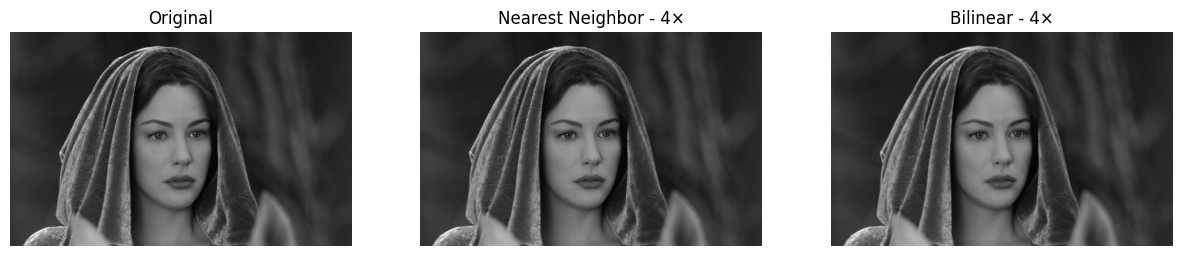

In [ ]:
plt.figure(figsize=(15,3))
## plot the original image, nearest neighbor interpolation, and bilinear interpolation results
plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis("off")
plt.subplot(1,3,2)
plt.imshow(nearest, cmap='gray')
plt.title("Nearest Neighbor - 4×")
plt.axis("off")
plt.subplot(1,3,3)
plt.imshow(bilinear, cmap='gray')
plt.title("Bilinear - 4×")
plt.axis("off")
plt.show()

In [ ]:
nearest_back = cv2.resize(nearest,(img.shape[1], img.shape[0]),interpolation=cv2.INTER_AREA)
bilinear_back = cv2.resize(bilinear,(img.shape[1], img.shape[0]),interpolation=cv2.INTER_AREA)
def normalized_ssd(original, reconstructed):
    original = original.astype(np.float32)
    reconstructed = reconstructed.astype(np.float32)
    numerator = np.sum((original - reconstructed) ** 2)
    denominator = np.sum(original ** 2)
    return numerator / denominator
nssd_nearest = normalized_ssd(img, nearest_back)
nssd_bilinear = normalized_ssd(img, bilinear_back)
print("Normalized SSD - Nearest:", nssd_nearest)
print("Normalized SSD - Bilinear:", nssd_bilinear)

Normalized SSD - Nearest: 0.004791657
Normalized SSD - Bilinear: 0.0045064837


The interpolation method with the lower normalized SSD provides a reconstruction that is more similar to the original image. Acoording to the results biliear interpolation gives similar image to the original one.
Nearest-neighbor and bilinear interpolation were implemented for image zooming. Nearest-neighbor interpolation assigns each new pixel the value of the closest original pixel, resulting in a blocky appearance at high magnification. Bilinear interpolation uses the four neighboring pixels and their relative distances, producing a smoother result. The normalized SSD was calculated after resizing the zoomed images back to the original dimensions. The method with the lower normalized SSD produced the reconstruction more similar to the original.

### (9).GrabCut segmentation

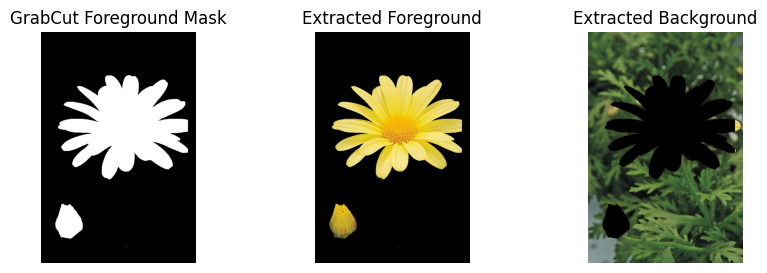

In [ ]:
img = cv2.imread(r"C:\my files\5th sem\CV\assignments\images\images\q9.jpeg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
cv2.GC_BGD   # 0
cv2.GC_FGD   # 1
cv2.GC_PR_BGD # 2
cv2.GC_PR_FGD # 3
mask = np.zeros(img.shape[:2], np.uint8)
mask[:] = cv2.GC_PR_BGD
h, w = img.shape[:2]
rect = (int(w * 0.05),int(h * 0.05),int(w * 0.90),int(h * 0.90))
bgdModel = np.zeros((1, 65), np.float64)
fgdModel = np.zeros((1, 65), np.float64)
cv2.grabCut(img,mask,rect,bgdModel,fgdModel,5,cv2.GC_INIT_WITH_RECT)
mask2 = np.where((mask == cv2.GC_FGD) | (mask == cv2.GC_PR_FGD),255,0).astype(np.uint8)
plt.figure(figsize=(10,3))
plt.subplot(1, 3, 1)
plt.imshow(mask2, cmap='gray')
plt.title("GrabCut Foreground Mask")
plt.axis("off");
## extract the foreground using the mask
foreground = cv2.bitwise_and(img,img,mask=mask2)
plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(foreground, cv2.COLOR_BGR2RGB))
plt.title("Extracted Foreground")
plt.axis("off");
## extract the background using the inverted mask
background_mask = cv2.bitwise_not(mask2)
background = cv2.bitwise_and(img,img,mask=background_mask)
plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(background, cv2.COLOR_BGR2RGB))
plt.title("Extracted Background")
plt.axis("off");

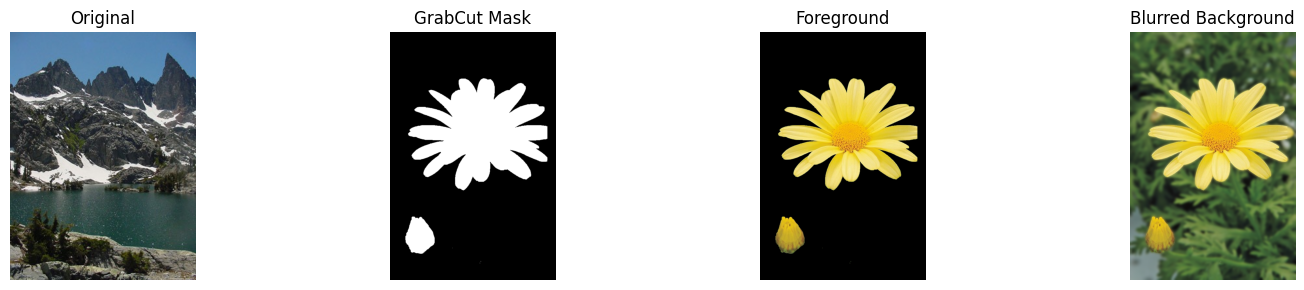

In [336]:
plt.figure(figsize=(16,3))
## plot the original image, GrabCut mask, extracted foreground, and the final result with blurred background
plt.subplot(1,4,1)
plt.imshow(img_rgb)
plt.title("Original")
plt.axis("off")
## plot the GrabCut mask
plt.subplot(1,4,2)
plt.imshow(mask2, cmap='gray')
plt.title("GrabCut Mask")
plt.axis("off")\
## plot the extracted foreground
plt.subplot(1,4,3)
plt.imshow(cv2.cvtColor(foreground, cv2.COLOR_BGR2RGB))
plt.title("Foreground")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title("Blurred Background")
plt.axis("off")
plt.tight_layout()
plt.show()

GrabCut was used to segment the flower from its background using an initial bounding rectangle. After several iterations, the resulting mask was used to extract the foreground and background. Gaussian blurring was then applied to the background while preserving the original foreground. Some dark regions may appear around the flower boundary because pixels classified as background are replaced by zero during foreground extraction.

### (10). Bilateral Filter

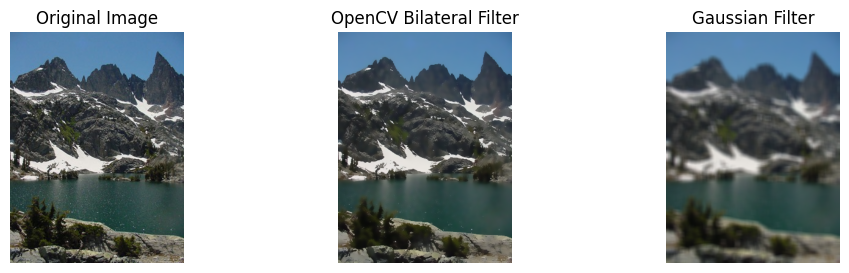

In [ ]:
img = cv2.imread(r"C:\my files\5th sem\CV\assignments\images\images\q10.jpeg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
## plots of the original image , OpenCV Bilateral filter image, gaussian filter image

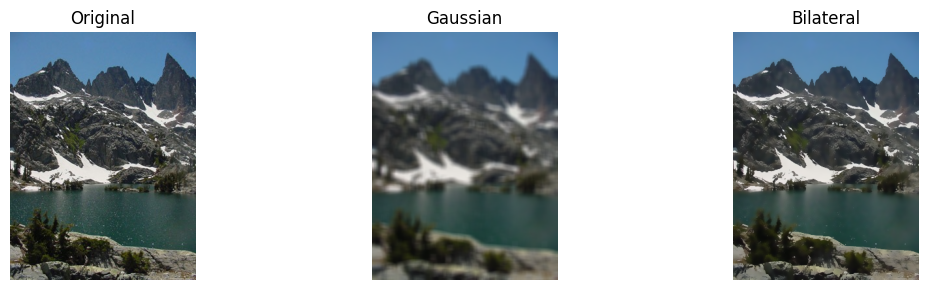

In [ ]:
## plots of thr original, gaussian, bilateral

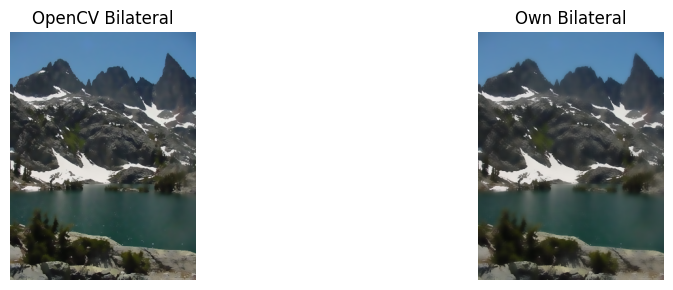

In [ ]:
## plots of the OpenCV Bilateral and implimented Bilateral images

In [ ]:
## define a function to compute the mean squared error (MSE) between two images
def mse(im1, im2):
    im1 = im1.astype(np.float32)
    im2 = im2.astype(np.float32)
    return np.mean((im1 - im2)**2)
mse_bilateral = mse(bilateral_cv_rgb,bilateral_own_rgb)
print("MSE between OpenCV and own bilateral:")
print(mse_bilateral)

MSE between OpenCV and own bilateral:
29.093817


In [ ]:
## compare the gaussian and bilateral filters using MSE
mse_gaussian = mse(img_rgb, gaussian_rgb   )
mse_bilateral = mse(img_rgb, bilateral_cv_rgb)
print("MSE - Gaussian:", mse_gaussian)
print("MSE - Bilateral:", mse_bilateral)

MSE - Gaussian: 561.01465
MSE - Bilateral: 57.782482


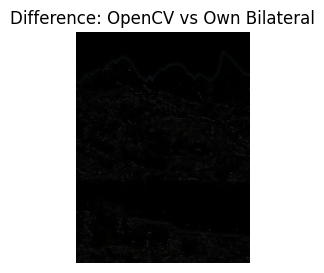

In [330]:
## compare the OpenCV and own bilateral filters
difference = cv2.absdiff(bilateral_cv_rgb,bilateral_own_rgb)
plt.figure(figsize=(7,3))
plt.imshow(difference, cmap='gray')
plt.title("Difference: OpenCV vs Own Bilateral")
plt.axis("off");

since the output is very dark that means our implementation is correct.
Bilateral filtering was applied to reduce image noise while preserving important edges. Unlike Gaussian filtering, which considers only the spatial distance between pixels, the bilateral filter also considers the intensity or color difference between neighboring pixels. Therefore, pixels with significantly different values have less influence on each other, helping to preserve edges while smoothing similar regions. The OpenCV and self-implemented bilateral filters produced similar results, demonstrating the correct implementation of the filtering process.